<a href="https://colab.research.google.com/github/polokocodes/Fashion-vision-model/blob/main/Fashion_vision_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# Import all relevant modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

In [20]:
fashion_data = pd.read_csv('/content/fashion-mnist_train.csv')
fashion_data.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
def preprocessing(fashion_data):
  print(f'Number of missing values: \n', fashion_data.isnull().sum())
  print(f'Fashion data columns: \n', fashion_data.columns)
  print(f'Fashion data shape: \n', fashion_data.shape)
  print(f'Fashion data info: \n', fashion_data.info)
  print(f'Fashion data describe: \n', fashion_data.describe())

  return fashion_data

preprocessing(fashion_data)


Number of missing values: 
 label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 785, dtype: int64
Fashion data columns: 
 Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='object', length=785)
Fashion data shape: 
 (60000, 785)
Fashion data info: 
 <bound method DataFrame.info of        label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0          2       0       0       0       0       0       0       0       0   
1          9       0       0       0       0       0       0       0       0   
2          6       0       0       0       0       0       0       0       5   
3          0       0       0       0       1       2       0       

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
label_counts = fashion_data['label'].value_counts().sort_index()
print(label_counts)

label
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64


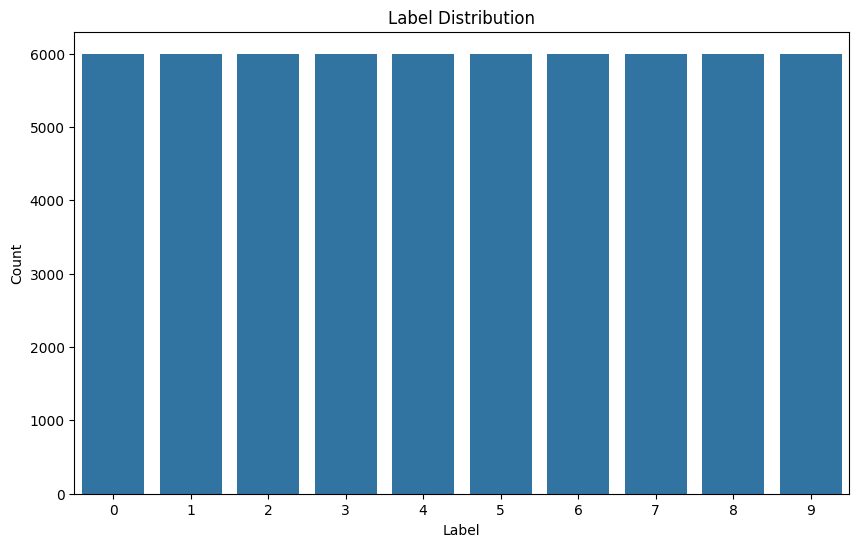

In [23]:
#Visualize the label data

plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Label Distribution')
plt.show()

Data processing results:

1.The data has no missing values

2.The data has 6000 rows and 785 columns

3.The target data is balanced as all labels are equall to 6000

In [24]:
# Separate features and target

X = fashion_data.drop('label', axis=1)
y = fashion_data['label']


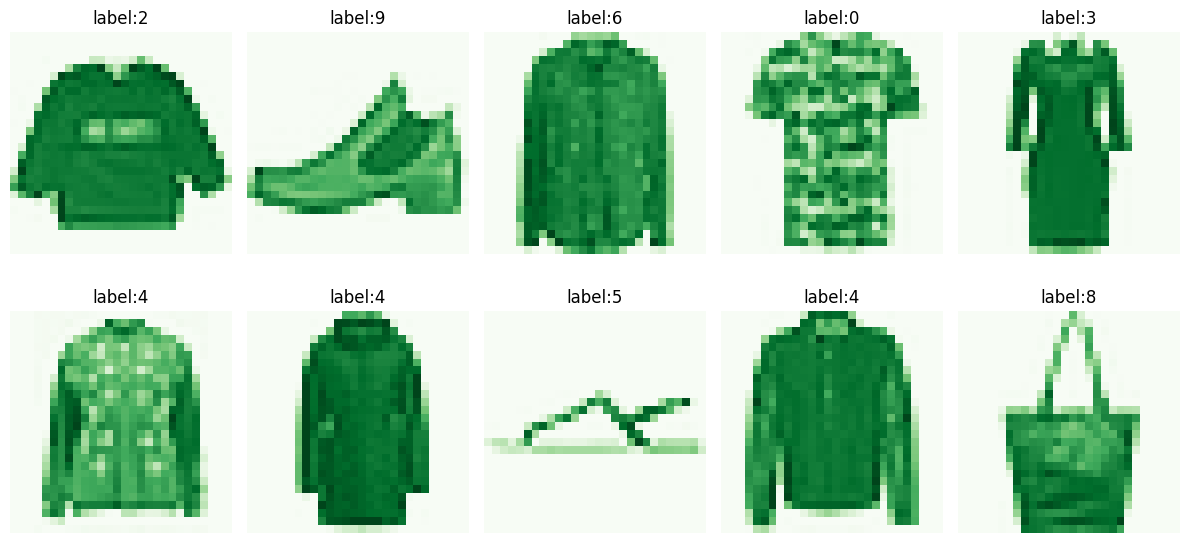

In [25]:
#Visualize a few pictures

plt.figure(figsize=(12,6))

for i in range(10):
  image = X.iloc[i].values.reshape(28,28)
  label = y.iloc[i]

  plt.subplot(2,5,i+1)
  plt.imshow(image, cmap='Greens')
  plt.title(f'label:{label}')
  plt.axis('off')

plt.tight_layout()
plt.show()

In [26]:
#Inspect 1 image as pixel values
simple_image = X.iloc[0].values.reshape(28,28)
simple_label = y.iloc[0]

print('Label: ', simple_label)
print(simple_image)

Label:  2
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   4   0   0   0   0   0  62  61  21  29  23  51 136  61
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  88 201 228 225 255 115  62 137 255 235 222
  255 135   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0  47 252 234 238 224 215 215 229 108 180 207 214 224
  231 249 254  45   0   0   0   0   0   0]
 [  0   0   1   0   0 214 222 210 213 224 225 217 220 254 233 219 221 217
  223 221 240 254   0   0   1   0   0   0]
 [  1   0   0   0 128 237 207 224 224 207 216 214 210 208 211 221 208 219
  213 226 211 237 150   0   0   0   0   0]
 [  0   2   0   0 237 222 215 207 210 212 213 206 214 

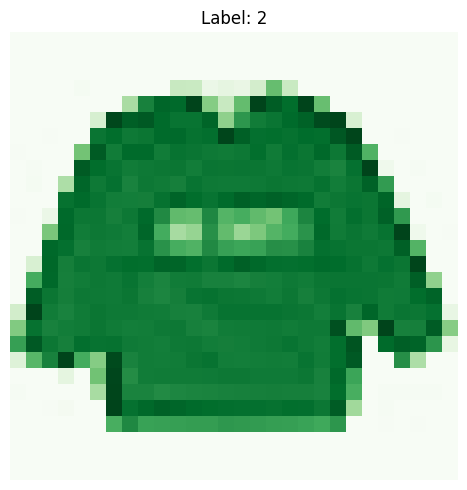

In [27]:
#Plot 1 image

plt.figure(figsize=(5,5))
plt.imshow(simple_image, cmap='Greens')
plt.title(f'Label: {simple_label}')
plt.axis('off')
plt.tight_layout()
plt.show()

In [30]:
# Normalize the features

X = X/255.0


In [31]:
#Split the data into train and validation data

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train shape: {X_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_val shape: {y_val.shape}')

X_train shape: (48000, 784)
X_val shape: (12000, 784)
y_train shape: (48000,)
y_val shape: (12000,)


In [32]:
# Train a simple classification model

FS_model = LogisticRegression()
FS_model.fit(X_train, y_train)

print("Model has been trained")

Model has been trained


In [34]:
# Make predictions
FS_model_pred = FS_model.predict(X_val)
print(f'First 10 predictions: {FS_model_pred[:10]}')

First 10 predictions: [7 8 8 5 9 1 2 3 5 4]


In [37]:
# Model evaluations
model_accuracy = accuracy_score(y_val, FS_model_pred)
print(f'Model accuracy: \n{model_accuracy}')

class_report = classification_report(y_val, FS_model_pred)
print(f'Classification report: \n{class_report}')

Model accuracy: 
0.6923333333333334
Classification report: 
              precision    recall  f1-score   support

           0       0.70      0.74      0.72      1232
           1       0.87      0.93      0.90      1174
           2       0.58      0.56      0.57      1200
           3       0.71      0.77      0.74      1242
           4       0.53      0.60      0.56      1185
           5       0.48      0.72      0.58      1141
           6       0.58      0.07      0.13      1243
           7       0.73      0.84      0.79      1224
           8       0.90      0.81      0.85      1149
           9       0.86      0.90      0.88      1210

    accuracy                           0.69     12000
   macro avg       0.69      0.69      0.67     12000
weighted avg       0.69      0.69      0.67     12000

